In [46]:
import pandas as pd
import numpy as np

Diana Morgan - 336472261, Oded Katz - 211862693

# Part 1
## Question 1
### Section a

In [47]:
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
np.random.seed(12345)

data = pd.read_csv('../hw3/metabric_imputed_data.csv')
y = Surv.from_dataframe('status', 'time', data)
X = data.drop(columns=['time', 'status'])

# convert categorcial variables to one-hot encoding
categorical_features = ['TUMOR_STAGE', 'ER_STATUS']
numeric_features = [col for col in data.columns if col not in categorical_features + ['time', 'status']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', "passthrough", numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

train_duration = y_train["time"]
train_event = y_train["status"].astype(bool)
test_duration = y_test["time"]
test_event = y_test["status"].astype(bool)

### Section b

In [48]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators = 1000,
    max_features="sqrt",
    min_samples_leaf=15,
    n_jobs=-1,
    random_state=12345
)

rsf_pipe = make_pipeline(preprocessor, rsf)
rsf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['FCER1A', 'PKMYT1',
                                                   'COL17A1', 'JCHAIN', 'STIP1',
                                                   'GSK3B', 'STAT5A', 'EZR',
                                                   'SPRY2', 'RACGAP1', 'ITM2A',
                                                   'KIF20A', 'TROAP', 'TP63',
                                                   'OGN', 'GLA', 'CDCA5',
                                                   'IGF1', 'CLDN11', 'GRHL2',
                                                   'CD1C', 'CLIC6', 'TK1',
                                                   'PCDH18', 'UBE2C', 'UHRF1',
                                                   'LAMA2', 'TPX2', 'LEPR',
                                                   'KLRB1', ...]),
                                                 ('cat

### Section c

In [49]:
from sklearn.preprocessing import StandardScaler
import torch
import torchtuples as tt
torch.manual_seed(12345)

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features),
    ]
)
 
X_train_nn = preprocessor_scaled.fit_transform(X_train).astype("float32")
X_test_nn = preprocessor_scaled.transform(X_test).astype("float32")

train_duration_np = train_duration.astype("float32")
train_event_np = train_event.astype("float32")
test_duration_np = test_duration.astype("float32")
test_event_np = test_event.astype("float32")

in_features = X_train_nn.shape[1]
num_nodes = [64, 32]
batch_norm = True
dropout = 0.1
lr = 0.001
epochs = 100
batch_size = 256

In [50]:
from pycox.models import CoxPH, CoxTime
from pycox.models.cox_time import MLPVanillaCoxTime


net_deepsurv = tt.practical.MLPVanilla(
    in_features, num_nodes, 1,
    batch_norm=batch_norm, dropout=dropout, output_bias=False,
)
deep_surv = CoxPH(net_deepsurv, tt.optim.Adam(lr))

deep_surv.fit(
    X_train_nn, (train_duration_np, train_event_np),
    batch_size=batch_size, epochs=epochs, verbose=False,
)

### Section d

In [51]:
labtrans_ct = CoxTime.label_transform()
y_train_ct = labtrans_ct.fit_transform(train_duration_np, train_event_np)
 
net_coxtime = MLPVanillaCoxTime(
    in_features, num_nodes,
    batch_norm=batch_norm, dropout=dropout,
)
 
cox_time = CoxTime(net_coxtime, tt.optim.Adam(lr), labtrans=labtrans_ct)
cox_time.fit(
    X_train_nn, y_train_ct,
    batch_size=batch_size, epochs=epochs, verbose=False,
)

### Section e

In [52]:
# i)
deep_surv.compute_baseline_hazards()
surv_ds = deep_surv.predict_surv_df(X_test_nn)

cox_time.compute_baseline_hazards()
surv_ct = cox_time.predict_surv_df(X_test_nn)

In [53]:
# ii)
def surv_at_t_for_nn(model, t, x_test_nn):
    surv = model.predict_surv_df(x_test_nn)
    return surv.reindex(surv.index.union([t])).sort_index().ffill().loc[t]

def surv_at_t(model_name, t, x_test, x_test_nn):
    if model_name == "RSF":
        surv_funcs = rsf_pipe.predict_survival_function(x_test)
        return np.array([sf(t) for sf in surv_funcs])
    elif model_name == "DeepSurv":
        return surv_at_t_for_nn(deep_surv, t, x_test_nn)
    elif model_name == "Cox-Time":
        return surv_at_t_for_nn(cox_time, t, x_test_nn)

### Section f

In [54]:
import matplotlib.pyplot as plt

def build_grid_data(var, x_train):
    min_val = x_train[var].min()
    max_val = x_train[var].max()
    grid = np.linspace(min_val, max_val, 100)

    fixed_values = {}
    for col in x_train.columns:
        if col == var:
            continue
        if col in categorical_features:
            fixed_values[col] = x_train[col].mode()[0]
        else:
            fixed_values[col] = x_train[col].mean()

    # build the whole grid frame in a single construction (no repeated inserts)
    x_grid = pd.DataFrame(
        {col: np.full(len(grid), val) for col, val in fixed_values.items()}
    )
    x_grid[var] = grid
    x_grid = x_grid[x_train.columns]

    return grid, x_grid

def cond_surv_data(var, x_train, t = 60):
    grid, x_grid = build_grid_data(var, x_train)

    # RSF: pipeline handles its own preprocessing, so pass raw covariates
    surv_funcs_rsf = rsf_pipe.predict_survival_function(x_grid)
    surv_rsf = np.array([sf(t) for sf in surv_funcs_rsf])

    # DeepSurv / Cox-Time: need the scaled/one-hot encoded design matrix
    x_grid_nn = preprocessor_scaled.transform(x_grid).astype("float32")
    surv_ds = surv_at_t("DeepSurv", t, x_grid, x_grid_nn)
    surv_ct = surv_at_t("Cox-Time", t, x_grid, x_grid_nn)

    return grid, surv_rsf, surv_ds, surv_ct

def plot_cond_surv(var, x_train, t = 60):
    grid, surv_rsf, surv_ds, surv_ct = cond_surv_data(var, x_train, t=t)
    plt.figure(figsize=(7, 5))
    plt.plot(grid, surv_rsf, label="RSF", color="tab:blue")
    plt.plot(grid, surv_ds, label="DeepSurv", color="tab:orange")
    plt.plot(grid, surv_ct, label="Cox-Time", color="tab:green")
    plt.xlabel(var)
    plt.ylabel(r"Predicted $\hat{S}(60\,|\,X)$")
    plt.title(f"Predicted 5-year survival probability vs. {var}")
    plt.legend()
    plt.tight_layout()
    plt.show()

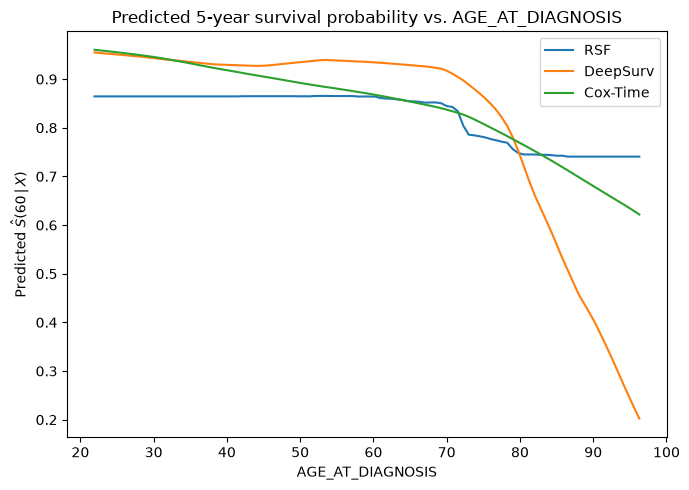

In [55]:
plot_cond_surv("AGE_AT_DIAGNOSIS", X_train, t=60)

The three models show similar associations between the age and predicted 5-year survival probability. As the age increases, the predicted 5-year survival probability decreases. The RSF and Cox-Time models show a more gradual decrease in survival probability with increasing age, while the DeepSurv model shows a steeper decline. Overall, all three models suggest that older patients have a lower predicted 5-year survival probability compared to younger patients.

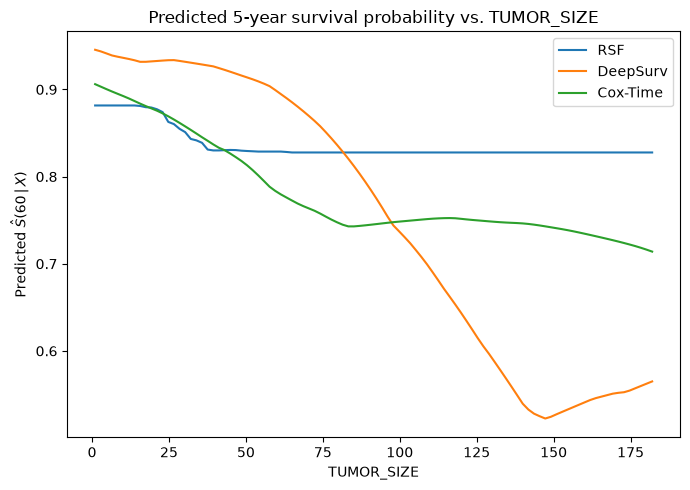

In [56]:
plot_cond_surv("TUMOR_SIZE", X_train, t=60)

The RSF and DeepSurv models show similar associations between the tumor size and predicted 5-year survival probability, with a decreasing trend that is somewhat constant for tumor sizes bigger than 50, but that is probably due to the fact that there are very few patients with tumor sizes bigger than 50. The Cox-Time model shows a steeper trend, with a decreasing trend for tumor sizes smaller than 50. When focusing on tumor sizes smaller than 50, all three models show a decreasing trend in predicted 5-year survival probability as tumor size increases, with the DeepSurv and Cox-Time models showing a very similar trend that steadily decreases, while the RSF model starts lower and decreases more gradually. Overall, all three models suggest that patients with larger tumor sizes have a lower predicted 5-year survival probability compared to patients with smaller tumor sizes.

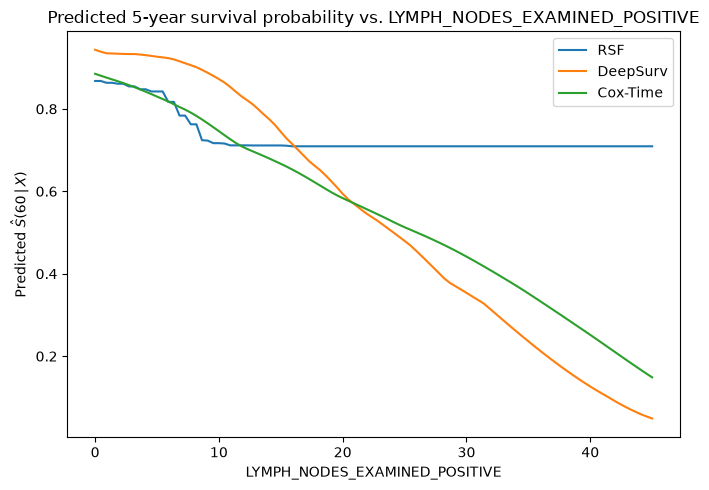

In [57]:
plot_cond_surv("LYMPH_NODES_EXAMINED_POSITIVE", X_train, t=60)

Examining the lymph nodes examined positive variable, we come to a similar pattern as with the tumor size variable, which is that most of the patients have a small number of positive lymph nodes, and therefore the models are more reliable for smaller values of this variable. For smaller values of the lymph nodes examined positive variable, all three models show a decreasing trend in predicted 5-year survival probability as the number of positive lymph nodes increases. As the number of positive lymph nodes increases the results become less reliable and the models show different trends.

### Section g

In [58]:
tau = np.percentile(train_duration, 90)
time_grid = np.linspace(0, tau, 100)

def surv_matrix_at_grid(surv_df, time_grid):
    full_index = surv_df.index.union(time_grid)
    surv_full = surv_df.reindex(full_index).sort_index().ffill()
    surv_full = surv_full.fillna(1.0)
    return surv_full.loc[time_grid].values.T

# ---- RSF ----
surv_funcs_rsf = rsf_pipe.predict_survival_function(X_test)
surv_rsf = np.array([sf(time_grid) for sf in surv_funcs_rsf])  # (n_test, 100)

# ---- DeepSurv ----
X_test_nn = preprocessor_scaled.transform(X_test).astype("float32")
surv_ds_df = deep_surv.predict_surv_df(X_test_nn)
surv_ds = surv_matrix_at_grid(surv_ds_df, time_grid)

# ---- Cox-Time ----
surv_ct_df = cox_time.predict_surv_df(X_test_nn)
surv_ct = surv_matrix_at_grid(surv_ct_df, time_grid)

# ---- assemble into one long-format dataframe ----
def to_long(surv_matrix, model_name, time_grid):
    n_patients, n_times = surv_matrix.shape
    return pd.DataFrame({
        "model": model_name,
        "patient": np.repeat(np.arange(n_patients), n_times),
        "tau": np.tile(time_grid, n_patients),
        "surv_prob": surv_matrix.flatten()
    })

surv_res = pd.concat([
    to_long(surv_rsf, "RSF", time_grid),
    to_long(surv_ds, "DeepSurv", time_grid),
    to_long(surv_ct, "Cox-Time", time_grid),
], ignore_index=True)

In [59]:
surv_res.head()

,model,patient,tau,surv_prob
0,RSF,0,0.000000,1.000000
1,RSF,0,2.359259,0.998539
2,RSF,0,4.718519,0.998073
3,RSF,0,7.077778,0.994696
4,RSF,0,9.437037,0.993532


### Section h

In [60]:
# i)
from sksurv.metrics import concordance_index_censored

s60_rsf = np.asarray(surv_at_t("RSF", 60, X_test, X_test_nn))
s60_ds  = np.asarray(surv_at_t("DeepSurv", 60, X_test, X_test_nn))
s60_ct  = np.asarray(surv_at_t("Cox-Time", 60, X_test, X_test_nn))

risk_scores = {
    "RSF": 1 - s60_rsf,
    "DeepSurv": 1 - s60_ds,
    "Cox-Time": 1 - s60_ct,
}

cindex = {
    name: concordance_index_censored(test_event, test_duration, r)[0]
    for name, r in risk_scores.items()
}

In [61]:
# ii)
from pycox.evaluation import EvalSurv
from pycox.utils import kaplan_meier
import scipy.integrate as spi

# SciPy >= 1.14 removed simps; pycox still calls it.
if not hasattr(spi, "simps"):
    spi.simps = lambda y, x=None, dx=1.0, axis=-1, even=None: spi.simpson(
        y, x=x, dx=dx, axis=axis
    )

# G = Kaplan-Meier estimate of the censoring distribution, fitted on the TRAINING data
g_train = kaplan_meier(train_duration_np, 1.0 - train_event_np)

def make_censor_df(surv_df):
    # broadcast the population-level training G onto the surv time index, one column per individual
    g = g_train.reindex(surv_df.index, method="ffill").fillna(1.0)
    return pd.DataFrame(
        np.repeat(g.values[:, None], surv_df.shape[1], axis=1),
        index=surv_df.index,
        columns=surv_df.columns,
    )

def calc_ibs(surv_df, test_duration, test_event, time_grid):
    ev = EvalSurv(
        surv_df,
        test_duration,
        test_event.astype(bool),
        censor_surv=make_censor_df(surv_df),
    )
    return ev.integrated_brier_score(time_grid=time_grid)

ibs = {
    "RSF": calc_ibs(pd.DataFrame(surv_rsf.T, index=time_grid), test_duration_np, test_event_np, time_grid),
    "DeepSurv": calc_ibs(surv_ds_df, test_duration_np, test_event_np, time_grid),
    "Cox-Time": calc_ibs(surv_ct_df, test_duration_np, test_event_np, time_grid),
}

In [62]:
# iii) results table
results_table = pd.DataFrame({
    "Model": list(cindex.keys()),
    "C-index": list(cindex.values()),
    "IBS": [ibs[m] for m in cindex.keys()],
})
results_table.round(2)

,Model,C-index,IBS
0,RSF,0.70,0.16
1,DeepSurv,0.65,0.21
2,Cox-Time,0.65,0.19


The results show RSF to have the highest C-index and lowest IBS, indicating that it has the best predictive performance among the three models.

### Section i

RSF achieved the best performance in terms of both C-index and IBS, indicating that it is the most accurate model for predicting survival outcomes in this dataset. The results based on the C-index and IBS metricsare consistent - as the C-index increases, the IBS decreases, indicating better predictive performance.

##### iv)

**RSF** Advantages: non-parametric, captures non-linearities and interactions automatically, no proportional-hazards assumption, robust with little tuning, and here gives the best C-index and lowest IBS. Limitations: less smooth/extrapolates poorly in sparse covariate regions (visible as the flat tails for large tumor size / many positive nodes), can be biased by heavy censoring, less interpretable, and memory/compute heavy with B=1000 trees on p≈105 predictors.

**DeepSurv** Advantages: flexible neural network that learns non-linear covariate effects while keeping a Cox-style partial-likelihood, scales to high dimensions. Limitations: still assumes proportional hazards (a single risk score, time-constant effects), needs feature scaling and careful tuning, prone to overfitting on this modest sample (worst IBS here), and low interpretability.

**Cox-Time** — Advantages: relaxes proportional hazards by letting the network take time as an input, so hazard ratios can vary over time — the most flexible of the three. Limitations: hardest to train and most data-hungry, higher variance / risk of overfitting on this sample size, slower (risk depends on time), and least interpretable; here it did not beat RSF.

**In this setting:** n/p is small (~1400 / 105), the signal in 100 SIS-selected genes is weak and noisy, and censoring is heavy. That regime favors the lower-variance, assumption-light method (RSF) over the two deep models, whose flexibility can't be paid for by this sample size. 

# Part 2
## Question 2
### Section a

In [63]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


data = pd.read_csv("hodgkin_competing_risks.csv")

train_data, test_data = train_test_split(
    data,
    test_size=0.30,
    random_state=11111
)

# Make independent copies
train_data = train_data.copy()
test_data = test_data.copy()


predictors = [
    "Age",
    "Sex",
    "Treatment",
    "Mediastinal_Involvement",
    "Extranodal_Disease",
    "Clinical_Stage"
]

categorical_predictors = [
    "Sex",
    "Treatment",
    "Mediastinal_Involvement",
    "Extranodal_Disease",
    "Clinical_Stage"
]

continuous_predictors = ["Age"]


# Treat missing categorical values as an explicit category
for variable in categorical_predictors:
    train_data[variable] = (
        train_data[variable]
        .astype("object")
        .fillna("Missing")
        .astype(str)
    )

    test_data[variable] = (
        test_data[variable]
        .astype("object")
        .fillna("Missing")
        .astype(str)
    )


print("Training observations:", len(train_data))
print("Test observations:", len(test_data))

print("\nMissing values in training data:")
print(train_data[predictors].isna().sum())

print("\nMissing values in test data:")
print(test_data[predictors].isna().sum())

Training observations: 605
Test observations: 260

Missing values in training data:
Age                        0
Sex                        0
Treatment                  0
Mediastinal_Involvement    0
Extranodal_Disease         0
Clinical_Stage             0
dtype: int64

Missing values in test data:
Age                        0
Sex                        0
Treatment                  0
Mediastinal_Involvement    0
Extranodal_Disease         0
Clinical_Stage             0
dtype: int64


### Section b

In [64]:
import numpy as np
import rpy2.robjects as ro

from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr


train_rsf = train_data[
    predictors + ["Time", "Status"]
].copy()

test_rsf = test_data[
    predictors + ["Time", "Status"]
].copy()


# Number of candidate variables at each split
p = len(predictors)
mtry = int(np.ceil(np.sqrt(p)))

print("p =", p)
print("mtry =", mtry)
print("RSF training rows:", len(train_rsf))
print("RSF test rows:", len(test_rsf))


# Transfer data from Python to R
with localconverter(
    ro.default_converter + pandas2ri.converter
):
    ro.globalenv["train_rsf"] = ro.conversion.py2rpy(
        train_rsf
    )

    ro.globalenv["test_rsf"] = ro.conversion.py2rpy(
        test_rsf
    )

ro.globalenv["mtry_value"] = mtry


importr("survival")
importr("randomForestSRC")


ro.r("""
categorical_variables <- c(
    "Sex",
    "Treatment",
    "Mediastinal_Involvement",
    "Extranodal_Disease",
    "Clinical_Stage"
)

# Convert categorical predictors to factors
train_rsf[categorical_variables] <-
    lapply(
        train_rsf[categorical_variables],
        factor
    )

# Use the training factor levels in the test data
for (variable in categorical_variables) {
    test_rsf[[variable]] <- factor(
        test_rsf[[variable]],
        levels = levels(train_rsf[[variable]])
    )
}

set.seed(11111)

rsf_cr <- rfsrc(
    Surv(Time, Status) ~ .,
    data = train_rsf,
    ntree = 1000,
    mtry = mtry_value,
    nodesize = 10,
    splitrule = "logrankCR"
)

rsf_cr_prediction <- predict(
    rsf_cr,
    newdata = test_rsf
)

# Relapse is cause 1
cif_relapse_rsf <- rsf_cr_prediction$cif[, , 1]

rsf_times <- rsf_cr_prediction$time.interest
""")


cif_relapse_rsf = np.asarray(
    ro.r("cif_relapse_rsf")
)

rsf_times = np.asarray(
    ro.r("rsf_times")
)


print("Relapse CIF shape:", cif_relapse_rsf.shape)
print("Number of RSF time points:", len(rsf_times))

p = 6
mtry = 3
RSF training rows: 605
RSF test rows: 260
Relapse CIF shape: (260, 26)
Number of RSF time points: 26


### Section c

In [65]:
import numpy as np
import torch
import torchtuples as tt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from pycox.models import DeepHit


np.random.seed(11111)
torch.manual_seed(11111)


X_train_df = train_data[predictors].copy()
X_test_df = test_data[predictors].copy()


preprocess_deephit = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_predictors
        ),
        (
            "continuous",
            StandardScaler(),
            continuous_predictors
        )
    ]
)


X_train_deephit = preprocess_deephit.fit_transform(
    X_train_df
).astype("float32")

X_test_deephit = preprocess_deephit.transform(
    X_test_df
).astype("float32")


num_risks = 2
num_durations = 30
num_nodes = [64, 32]
batch_norm = True
dropout = 0.1
learning_rate = 0.001
epochs = 200
batch_size = 128


train_time_index = (
    train_data["Time"].to_numpy(dtype=np.int64) - 1
)

train_status_deephit = train_data[
    "Status"
].to_numpy(dtype=np.int64)

y_train_deephit = (
    train_time_index,
    train_status_deephit
)


class CauseTimeNet(torch.nn.Module):

    def __init__(
        self,
        in_features,
        num_nodes,
        num_risks,
        num_durations,
        batch_norm,
        dropout
    ):
        super().__init__()

        self.num_risks = num_risks
        self.num_durations = num_durations

        self.mlp = tt.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=num_nodes,
            out_features=num_risks * num_durations,
            batch_norm=batch_norm,
            dropout=dropout
        )

    def forward(self, x):
        output = self.mlp(x)

        return output.view(
            -1,
            self.num_risks,
            self.num_durations
        )


net_deephit = CauseTimeNet(
    in_features=X_train_deephit.shape[1],
    num_nodes=num_nodes,
    num_risks=num_risks,
    num_durations=num_durations,
    batch_norm=batch_norm,
    dropout=dropout
)


deephit_times = np.arange(
    1,
    num_durations + 1,
    dtype=np.float32
)


deephit_cr = DeepHit(
    net_deephit,
    tt.optim.Adam(lr=learning_rate),
    alpha=0.2,
    sigma=0.1,
    duration_index=deephit_times
)


deephit_log = deephit_cr.fit(
    X_train_deephit,
    y_train_deephit,
    batch_size=batch_size,
    epochs=epochs,
    verbose=False
)


cif_deephit = deephit_cr.predict_cif(
    X_test_deephit
)

cif_relapse_deephit = cif_deephit[0].T


print("Full DeepHit CIF shape:", cif_deephit.shape)
print("Relapse CIF shape:", cif_relapse_deephit.shape)

Full DeepHit CIF shape: (2, 30, 260)
Relapse CIF shape: (260, 30)


### Section d

In [66]:
import numpy as np
import pandas as pd


# Follow-up intervals requested 
evaluation_times = [5, 10, 20]


def cif_at_time(cif_matrix, time_grid, time):
    """
    Return the predicted CIF for every individual at a requested time.

    cif_matrix:
        Rows are individuals and columns are prediction times.

    time_grid:
        Times corresponding to the columns of cif_matrix.
    """

    time_grid = np.asarray(time_grid)

    # Find the last available prediction time that is <= time
    column_index = np.searchsorted(
        time_grid,
        time,
        side="right"
    ) - 1

    # If the requested time is before the first prediction time,
    # the cumulative incidence is zero
    if column_index < 0:
        return np.zeros(cif_matrix.shape[0])

    return cif_matrix[:, column_index]


# Store the average predicted relapse CIFs
results = []

for time in evaluation_times:

    # Predicted relapse CIF for every test individual
    rsf_cif_at_time = cif_at_time(
        cif_relapse_rsf,
        rsf_times,
        time
    )

    deephit_cif_at_time = cif_at_time(
        cif_relapse_deephit,
        deephit_times,
        time
    )

    # Average across all test individuals
    results.append({
        "Follow-up interval": time,
        "RSF-CR": np.mean(rsf_cif_at_time),
        "DeepHit": np.mean(deephit_cif_at_time)
    })


# Report both models in one table
average_cif_table = pd.DataFrame(results)

average_cif_table

,Follow-up interval,RSF-CR,DeepHit
0,5,0.294941,0.263437
1,10,0.331961,0.308918
2,20,0.351211,0.343901


### Section e

In [67]:
from pycox.utils import kaplan_meier

# Test outcomes 
Y_test = test_data["Time"].to_numpy(dtype=float)
J_test = test_data["Status"].to_numpy(dtype=float)   

# G-hat: KM of the censoting distribution, fitted on the training data 
train_time = train_data["Time"].to_numpy(dtype=float)
train_status = train_data["Status"].to_numpy(dtype=float)
censor_indicator = (train_status == 0).astype(float)

G_series = kaplan_meier(train_time, censor_indicator)   


def eval_step(series, times):
    """Evaluate a right-continuous step function at `times`:
    take the value at the largest index time <= t (and 1.0 before the first jump)."""
    idx = np.asarray(series.index, dtype=float)
    vals = np.asarray(series.values, dtype=float)
    times = np.atleast_1d(np.asarray(times, dtype=float))
    pos = np.searchsorted(idx, times, side="right") - 1
    out = np.where(
        pos >= 0, 
        vals[np.clip(pos, 0, len(vals) - 1)],
        1.0
        )
    return out


# Predicted relapse CIF on the full grid t = 1-30 for every test individual
grid = np.arange(1, num_durations + 1) 


def cif_on_grid(cif_matrix, cif_times, grid):
    """Step the CIF (individuals x cif_times) onto `grid` using the last time <= t
    (largest observed event time not exceeding t); CIF is 0 before the first time."""
    cif_times = np.asarray(cif_times, dtype=float)
    pos = np.searchsorted(cif_times, grid, side="right") - 1
    out = np.zeros((cif_matrix.shape[0], len(grid)))
    for j, p in enumerate(pos):
        if p >= 0:
            out[:, j] = cif_matrix[:, p]
    return out


F1_rsf = cif_on_grid(cif_relapse_rsf, rsf_times, grid)
F1_deephit = cif_on_grid(cif_relapse_deephit, deephit_times, grid)


def competing_risks_ibs(F1, grid, Y, J, G_series, g_floor=1e-8):
    """Cause-specific (relapse, r=1) IBS with IPCW weights, per the assignment."""
    G_Yi = np.clip(eval_step(G_series, Y), g_floor, None)   
    bs_t = np.zeros(len(grid))
    for j, t in enumerate(grid):
        G_t = max(eval_step(G_series, t)[0], g_floor)
        w = (((Y <= t) & (J != 0)).astype(float) / G_Yi) + ((Y > t).astype(float) / G_t)
        obs = ((Y <= t) & (J == 1)).astype(float)
        bs_t[j] = np.mean(w * (obs - F1[:, j]) ** 2)
        
    return bs_t.mean(), bs_t   # IBS = (1/30) * sum_t BS1(t)


ibs_rsf, bs_rsf = competing_risks_ibs(F1_rsf, grid, Y_test, J_test, G_series)
ibs_deephit, bs_deephit = competing_risks_ibs(F1_deephit, grid, Y_test, J_test, G_series)

ibs_table = pd.DataFrame({
    "Model": ["RSF-CR", "DeepHit"],
    "IBS (relapse)": [ibs_rsf, ibs_deephit],
})
ibs_table.round(4)

,Model,IBS (relapse)
0,RSF-CR,0.2230
1,DeepHit,0.2216


### Section f

**i) Lower IBS.** DeepHit achieved the lower IBS (0.2216 vs. 0.2230 for RSF-CR), but the gap is tiny, so the two methods are essentially equivalent in predictive accuracy for relapse.

**ii) Predicted CIFs at t = 5, 10, 20.** The average predicted relapse incidences were very similar across the two methods (RSF-CR ≈ 0.29 / 0.33 / 0.35 vs. DeepHit ≈ 0.26 / 0.31 / 0.34), with RSF-CR slightly higher at every interval. Both agree that relapse risk accrues mainly in the early intervals and then flattens — consistent with their near-equal IBS.